# GPAW + WannierBerri: spinless bandstructure (diamond)

This tutorial demonstrates how to wannierize a **spinless** bandstructure of diamond

## Prerequisites
Make sure you have installed the following packages:

```
pip install wannierberri gpaw ase irrep
```

## Step 1: Gpaw calculation

### self-consistent calculation

In [2]:
import numpy as np
from ase import Atoms
from gpaw import GPAW, PW, MixerSum
from irrep.spacegroup import SpaceGroup
seed = "diamond"


In [ ]:

a = 3.227
lattice = a * (np.ones((3, 3)) - np.eye(3)) / 2
positions = np.array([[0, 0, 0], [1, 1, 1]])/4
typeat = [1, 1]
atoms = Atoms(
    "C2", cell=lattice, pbc=[1, 1, 1], scaled_positions=positions
)

calc = GPAW(
    mode=PW(500),
    xc="PBE",
    symmetry={'symmorphic': False},
    kpts={"size": [8, 8, 8], "gamma": True},
    convergence={"density": 1e-6},
    mixer=MixerSum(0.25, 8, 100),
    txt=f"{seed}-scf.txt"
)

atoms.calc = calc
atoms.get_potential_energy()
calc.write(f"{seed}-scf.gpw", mode="all")


### Non-self-consistent calculation in the irreducible Brillouin zone

Now we get the list of irreducible k-points (using irrep.SpaceGroup object) and perform a non-self-consistent calculation only on these k-points. 
We use irrep (instead of internal GPAW symmetrization), because it cann account for non-symmorphic symmetries, and also magnetic symmetries (see other tutorials)

In [2]:
calc_scf = GPAW(f'{seed}-scf.gpw', txt=None)
sg = SpaceGroup.from_gpaw(calc_scf)
sg.show()
irred_kpt = sg.get_irreducible_kpoints_grid((4, 4, 4))
calc_nscf_irred = calc_scf.fixed_density(
    kpts=irred_kpt,
    symmetry={'symmorphic': False},
    nbands=20,
    convergence={'bands': 20},
    txt=f'{seed}-nscf-irred.txt')
calc_nscf_irred.write(f'{seed}-nscf.gpw', mode='all')

typat used for spacegroup detection (accounting magmoms): [6 6]


 ---------- CRYSTAL STRUCTURE ---------- 


Cell vectors in angstroms:

      Vectors of DFT cell       
a0 =  0.0000   1.6135   1.6135  
a1 =  1.6135   0.0000   1.6135  
a2 =  1.6135   1.6135   0.0000  



 ---------- SPACE GROUP ----------- 


Space group: Fd-3m1' (# 227.129)
Number of symmetries: 96 (mod. lattice translations)

 ### 1 

rotation : |  1   0   0 |
           |  0   1   0 |
           |  0   0   1 |


 gk = [kx, ky, kz]

translation         :  [   0.0000   0.0000   0.0000 ] 

axis: [ 0.091821 -0.314892  0.944676] ; angle =  0 , inversion: False, time reversal: False

 ### 2 

rotation : |  1   0   0 |
           |  0   1   0 |
           |  0   0   1 |


 gk = [-kx, -ky, -kz]

translation         :  [   0.0000   0.0000   0.0000 ] 

axis: [ 0.091821 -0.314892  0.944676] ; angle =  0 , inversion: False, time reversal: True

 ### 3 

rotation : |  1   1   1 |
           |  0   0  -1 |
           | -1   0   

### Compute the dft bandstructure along a high-symmetry path

This is done to compare with the wannierized bandstructure later.

In [3]:
calc_bands = GPAW(f"{seed}-scf.gpw",).fixed_density(
    nbands=16,
    symmetry='off',
    kpts={'path': 'WLGXWKG', 'npoints': 60},
    convergence={'bands': 8})
calc_bands.write(f"{seed}-bands.gpw", mode="all")


  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  25.7.0
 |___|_|             

User:   stepan@C3MP-C019202L
Date:   Thu Apr  2 12:57:27 2026
Arch:   x86_64
Pid:    15866
CWD:    /home/stepan/github/WannierBerri-tutorial/tutorials/8_GPAW/1.diamond
Python: 3.12.12
gpaw:   /home/stepan/github/WannierBerri-tutorial/.conda/lib/python3.12/site-packages/gpaw
_gpaw:  /home/stepan/github/WannierBerri-tutorial/.conda/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/stepan/github/WannierBerri-tutorial/.conda/lib/python3.12/site-packages/ase (version 3.26.0)
numpy:  /home/stepan/github/WannierBerri-tutorial/.conda/lib/python3.12/site-packages/numpy (version 2.3.4)
scipy:  /home/stepan/github/WannierBerri-tutorial/.conda/lib/python3.12/site-packages/scipy (version 1.16.2)
libxc:  5.2.3
units:  Angstrom and eV
cores: 1
OpenMP: False
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: 8}
  gpts: [12 12 12]
  kpt

Timing:                              incl.     excl.
-----------------------------------------------------------
Hamiltonian:                         0.019     0.000   0.0% |
 Atomic:                             0.017     0.000   0.0% |
  XC Correction:                     0.017     0.017   0.1% |
 Calculate atomic Hamiltonians:      0.000     0.000   0.0% |
 Communicate:                        0.000     0.000   0.0% |
 Initialize Hamiltonian:             0.000     0.000   0.0% |
 Poisson:                            0.000     0.000   0.0% |
 XC 3D grid:                         0.002     0.002   0.0% |
LCAO initialization:                 0.642     0.006   0.0% |
 LCAO eigensolver:                   0.181     0.001   0.0% |
  Calculate projections:             0.002     0.002   0.0% |
  DenseAtomicCorrection:             0.006     0.006   0.0% |
  Distribute overlap matrix:         0.001     0.001   0.0% |
  Orbital Layouts:                   0.008     0.008   0.1% |
  Potential matrix:

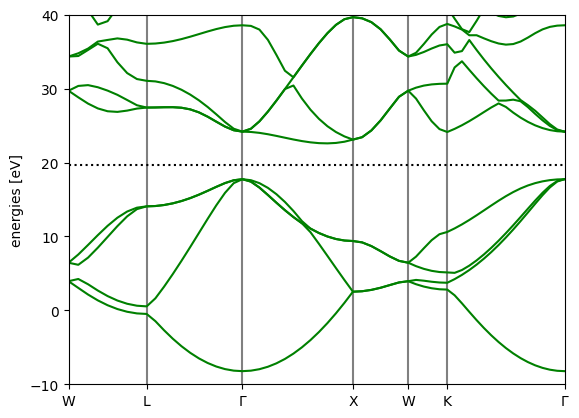

<Axes: ylabel='energies [eV]'>

In [4]:

calc_bands = GPAW(f"{seed}-bands.gpw",)
bs_dft = calc_bands.band_structure()
bs_dft.plot(show=True, emax=40.0)

## Step 2: Wannierization

#### 2.1 select projections

In this case we use sp3 projections on each carbon atom.

In [20]:
from wannierberri.symmetry.projections import Projection, ProjectionsSet
from wannierberri.w90files import WannierData

calc_scf = GPAW(f'{seed}-scf.gpw', txt=None)
sg = SpaceGroup.from_gpaw(calc_scf)

positions = sg.positions

proj_sp3 = Projection(
    position_num=positions,
    orbital='sp3',
    spacegroup=sg,
    rotate_basis=True
)

proj_set = ProjectionsSet(projections=[proj_sp3])




typat used for spacegroup detection (accounting magmom): [6 6]


### create the "w90 files"

Here we are NOT using the gpaw-wannier90 interface, and actually not creating the w90 files, but directly access the wavefunctions from the GPAW calculation, use symmetry operations from irrep, and create the necessary data to be used with wannierberri. Those files still retain the same naming convention as the w90 files for consistency, but htey are binary npz files, which are convenient to work with numpy

In [21]:

# seedname_ref = os.path.join(path_data, "diamond-irred")
calc_nscf_irred = GPAW(f'{seed}-nscf.gpw', txt=None)
wandata, bandstructure = WannierData.from_gpaw(
    calculator=calc_nscf_irred,
    spin_channel=0,
    projections=proj_set,
    select_grid=(4,4,4),
    irreducible=True,
    files=["amn", "mmn", "eig", "symmetrizer"],
    unitary_params=dict(error_threshold=0.1,
                        warning_threshold=0.01,
                        nbands_upper_skip=8),
    return_bandstructure=True
)
wandata.to_npz(f"{seed}-sp3")


finding num points from 1 projections
finding num points from 1 projections
got irreducible=True, mp_grid=None, seedname=wannier, files=['amn', 'mmn', 'eig', 'symmetrizer'],  projections=ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.0, 0.0, 0.0:['sp3'] with 8 Wannier functions (8 per spin x1 spins) 
 on 2 points (4 per site), unk_grid=None, normalize=True
self.irreducible=True
mpgrid = [4 4 4], 8
Shells found with weights [0.52755554] and tolerance 3.861271010427486e-16
Creating amn. Using projections_set 
ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.0, 0.0, 0.0:['sp3'] with 8 Wannier functions (8 per spin x1 spins) 
 on 2 points (4 per site)
NK= 64, selected_kpoints = [0 1 2 3 4 5 6 7], kptirr = [0 1 2 3 4 5 6 7]
saving to diamond-sp3.sawf.npz : 
saving to diamond-sp3.bkvec.npz : 
saving to diamond-sp3.chk.npz : 
saving to diamond-sp3.eig.npz : 
saving to diamond-sp3.amn.npz : 
saving to diamond-sp3.mmn.npz : 


In [28]:
wandata.wannierise(
    froz_min=-10,
    froz_max=30,
    outer_min=-10,
    outer_max=np.inf,
    num_iter=100,
    conv_tol=1e-10,
    print_progress_every=20,
    sitesym=True,
    localise=True,
)
wandata.chk.to_npz(f"{seed}-sp3.chk.npz")


/home/stepan/github/wannier-berri/wannierberri/wannierisation/wannierizer.py:248: UserWarning: Ray is not initialized, running in serial mode
  warnings.warn("Ray is not initialized, running in serial mode")


####################################################################################################
starting WFs
----------------------------------------------------------------------------------------------------
wannier centers and spreads
----------------------------------------------------------------------------------------------------
  0.131975696017    0.131975696017    0.131975696017   |     0.792353234598
  0.131975696017   -0.131975696017   -0.131975696017   |     0.792353234598
 -0.131975696017    0.131975696017   -0.131975696017   |     0.792353234598
 -0.131975696017   -0.131975696017    0.131975696017   |     0.792353234598
  0.674774303983    0.938725696017    0.938725696017   |     0.792353234598
  0.938725696017    0.938725696017    0.674774303983   |     0.792353234598
  0.674774303983    0.674774303983    0.674774303983   |     0.792353234598
  0.938725696017    0.674774303983    0.938725696017   |     0.792353234598
------------------------------------------------

### Create the System object to be used in WannierBerri calculations

It is called "System_w90" class, although it now does not use the w90 wannierization, but the class is the same.

In [23]:
from wannierberri import System_R
system = System_R.from_wannierdata(wandata=wandata, berry=True)

irreducible : True, symmetrize set to True
setting Rvec
setting AA..
setting AA - OK
Real-space lattice:
 [[0.     1.6135 1.6135]
 [1.6135 0.     1.6135]
 [1.6135 1.6135 0.    ]]
Number of wannier functions: 8
Number of R points: 123
Recommended size of FFT grid [4 4 4]
num_blocks_left = 1, num_blocks_right = 1
number o R-vectors before symmetrization: 123
number o R-vectors after symmetrization: 291


## Step 3: Compute the wannierized bandstructure along the high-symmetry path

### create the k path for wannierberri

In [24]:
from wannierberri.evaluate_k import evaluate_k_path
from wannierberri.grid import Path
kpoints = {
    'G': [0.0, 0.0, 0.0],
    'X': [0.5, 0.0, 0.5],
    'W': [0.5, 0.25, 0.75],
    'L': [0.5, 0.5, 0.5],
    'K': [0.375, 0.375, 0.75],
}

path_labels = "WLGXWKG"

path = Path.from_nodes(real_lattice=system.real_lattice,
                       nodes=[kpoints[label] for label in path_labels],
                       labels=list(path_labels),
                    length=100
)

bands_wannier= evaluate_k_path(system, path=path)  # length~=2pi/dk




Starting run()
Using the follwing calculators : 
############################################################

 'tabulate'  :  <wannierberri.calculators.tabulate.TabulatorAll object at 0x79b35627eab0>  : 
    TabulatorAll - a pack of all k-resolved calculators (Tabulators)
    
 Includes the following tabulators : 
--------------------------------------------------
 "Energy" : <wannierberri.calculators.tabulate.Energy object at 0x79b357207bf0> : calculator not described

--------------------------------------------------

############################################################
Calculation along a path - checking calculators for compatibility
tabulate <wannierberri.calculators.tabulate.TabulatorAll object at 0x79b35627eab0>
All calculators are compatible
Symmetrization switched off for Path
Grid is regular
The set of k points is a Path() with 140 points and labels {0: 'W', 22: 'L', 49: 'G', 80: 'X', 95: 'W', 106: 'K', 139: 'G'}
generating K_list
Done 
Done, sum of weights:140.0

##

/home/stepan/github/wannier-berri/wannierberri/run_grid.py:207: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


### Plot the bandstructures

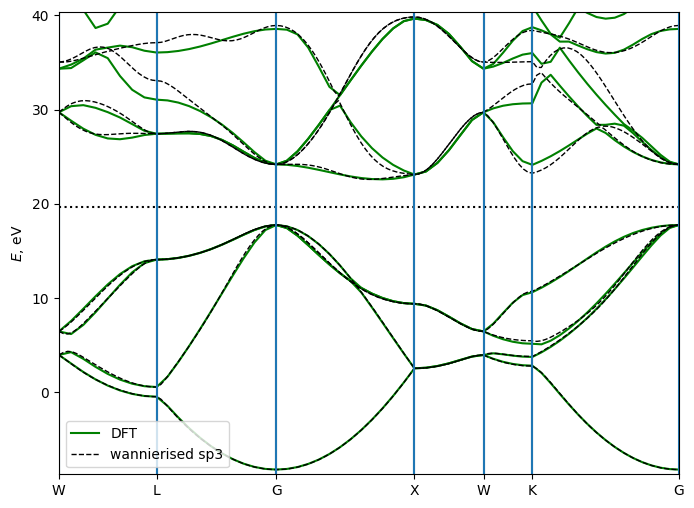

In [25]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
bs_dft.plot(show=False, emax=40.0, ax=ax, label="DFT")
bands_wannier.plot_path_fat(path=path,
                       label="wannierised sp3",
                        # linecolor="orange",
                        axes=ax,
                        close_fig=False,
                        show_fig=False,
                        kwargs_line=dict(linestyle='--', lw=1.0),
    )
plt.show()



One can see that the wannierized bandstructure (dashed lines) well reproduces the DFT bandstructure (solid lines) in the energy window of interest. Note, that we started from a very coarse DFT grid of 4,4,4 k-points, and still obtained a good agreement after wannierization. You may try to increase the grid on the nscf step, and see how it improves the agreement further.

## Bonding and antibonding states

Another option for projections is to use bonding and antibonding states. For that we place the wannier centers on the centers of the bonds, and use s-type projections (or bonding and pz-type for antibonding states, with the "z-axis" along the bond direction [111]. Note, that we specify only one bond position, the other 3 are generated by symmetry operations, and their "zaxis" are also rotated accordingly. 

Bonding states describe the valence bands, while antibonding states describe the conduction bands, so they can be wannierised separately.

In [32]:
proj_bonding = Projection(
    position_num=[1/8, 1/8, 1/8],
    orbital='s',
    spacegroup=sg,
    rotate_basis=True
)
proj_antibonding = Projection(
    position_num=[1/8, 1/8, 1/8],
    orbital='pz',
    zaxis=[1,1,1],
    rotate_basis=True,
    spacegroup=sg)

proj_set_bonding = ProjectionsSet(projections=[proj_bonding, proj_antibonding])

wandata_bonding = WannierData.from_npz(f"{seed}-sp3", files=["mmn", "symmetrizer", "eig"])
# seedname_ref = os.path.join(path_data, "diamond-irred")
wandata_bonding.set_projections(projections=proj_set_bonding, bandstructure=bandstructure)

wandata_bonding.wannierise(
    init="amn",
    froz_min=-10,
    froz_max=30,
    num_iter=1000,
    conv_tol=1e-10,
    print_progress_every=20,
    sitesym=True,
    localise=True
)
wandata_bonding.to_npz(f"{seed}-bonding")


system_bonding = System_R.from_wannierdata(wandata=wandata, berry=True)
bands_wannier_bonding = evaluate_k_path(system_bonding,
                                        path=path,
                                        return_path=False)

files = ['mmn', 'symmetrizer', 'eig', 'bkvec']
Trying to read file mmn from npz diamond-sp3.mmn.npz
setting file mmn from npz diamond-sp3.mmn.npz as <wannierberri.w90files.mmn.MMN object at 0x79b3553e8620>
Trying to read file symmetrizer from npz diamond-sp3.symmetrizer.npz
setting file symmetrizer from npz diamond-sp3.sawf.npz as <wannierberri.symmetry.sawf.SymmetrizerSAWF object at 0x79b3553eb2f0>
Trying to read file eig from npz diamond-sp3.eig.npz
setting file eig from npz diamond-sp3.eig.npz as <wannierberri.w90files.eig.EIG object at 0x79b3559a2b70>
Trying to read file bkvec from npz diamond-sp3.bkvec.npz
setting file bkvec from npz diamond-sp3.bkvec.npz as <wannierberri.w90files.bkvectors.BKVectors object at 0x79b356a657c0>


/home/stepan/github/wannier-berri/wannierberri/w90files/wandata.py:405: UserWarning: file mmn cntains 8 k-points less than NK (64) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/home/stepan/github/wannier-berri/wannierberri/w90files/wandata.py:405: UserWarning: file eig cntains 8 k-points less than NK (64) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "
/home/stepan/github/wannier-berri/wannierberri/w90files/wandata.py:405: UserWarning: file bkvec cntains 8 k-points less than NK (64) , so we assume the files contain only on irreducible k-points
  warnings.warn(f"file {f} cntains {nkeys} k-points less than NK ({NK}) , "


Setting AMN with kwargs={'kptirr': array([0, 1, 2, 3, 4, 5, 6, 7]), 'NK': array(64), 'selected_kpoints': array([0, 1, 2, 3, 4, 5, 6, 7])}
finding num points from 2 projections
finding num points from 2 projections
Creating amn. Using projections_set 
ProjectionsSet with 8 Wannier functions and 0 free variables
Projection 0.125, 0.125, 0.125:['s'] with 4 Wannier functions (4 per spin x1 spins) 
 on 4 points (1 per site)
Projection 0.125, 0.125, 0.125:['pz'] with 4 Wannier functions (4 per spin x1 spins) 
 on 4 points (1 per site)
AMN file created with NK=64


/home/stepan/github/wannier-berri/wannierberri/wannierisation/wannierizer.py:248: UserWarning: Ray is not initialized, running in serial mode
  warnings.warn("Ray is not initialized, running in serial mode")


####################################################################################################
starting WFs
----------------------------------------------------------------------------------------------------
wannier centers and spreads
----------------------------------------------------------------------------------------------------
  0.403375000000    0.403375000000    0.403375000000   |     0.717340997200
  0.403375000000    1.210125000000    1.210125000000   |     0.717340997200
  1.210125000000    1.210125000000    0.403375000000   |     0.717340997200
  1.210125000000    0.403375000000    1.210125000000   |     0.717340997200
  0.403375000000    0.403375000000    0.403375000000   |     1.748464055419
  0.403375000000    1.210125000000    1.210125000000   |     1.748464055419
  1.210125000000    1.210125000000    0.403375000000   |     1.748464055419
  1.210125000000    0.403375000000    1.210125000000   |     1.748464055419
------------------------------------------------

/home/stepan/github/wannier-berri/wannierberri/run_grid.py:207: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


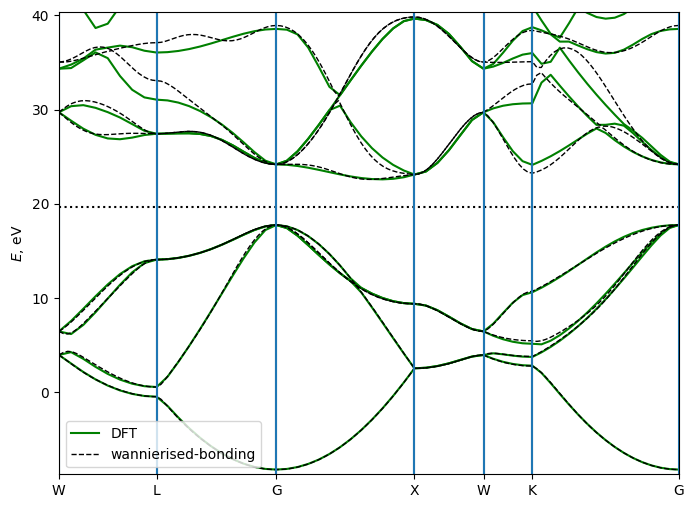

In [33]:
from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(8,6))
bs_dft.plot(filename='bandstructure.png', show=False, emax=40.0, ax=ax, label="DFT")
bands_wannier_bonding.plot_path_fat(path=path,
                       label="wannierised-bonding",
                        # linecolor="orange",
                        axes=ax,
                        close_fig=False,
                        show_fig=False,
                        kwargs_line=dict(linestyle='--', lw=1.0),
    )
plt.show()

### Save the system objects for later use

In [35]:
system_bonding.save_npz("system-diamond-bonding")
system.save_npz("system-diamond-sp3")

# load the system later
from wannierberri.system.system_R import System_R 
system_loaded = System_R.from_npz("system-diamond-sp3")

saving system of class System_R to system-diamond-bonding
 properties: ['num_wann', 'real_lattice', 'iRvec', 'periodic', 'is_phonon', 'wannier_centers_cart', 'pointgroup']
saving num_wann
saving num_wann to system-diamond-bonding/num_wann.npz
 - Ok!
saving real_lattice
saving real_lattice to system-diamond-bonding/real_lattice.npz
 - Ok!
saving iRvec
saving iRvec to system-diamond-bonding/iRvec.npz
 - Ok!
saving periodic
saving periodic to system-diamond-bonding/periodic.npz
 - Ok!
saving is_phonon
saving is_phonon to system-diamond-bonding/is_phonon.npz
 - Ok!
saving wannier_centers_cart
saving wannier_centers_cart to system-diamond-bonding/wannier_centers_cart.npz
 - Ok!
saving pointgroup
saving pointgroup to system-diamond-bonding/pointgroup.npz
 - Ok!
saving Ham - Ok!
saving AA - Ok!
saving system of class System_R to system-diamond-sp3
 properties: ['num_wann', 'real_lattice', 'iRvec', 'periodic', 'is_phonon', 'wannier_centers_cart', 'pointgroup']
saving num_wann
saving num_wann t